# Week 1 — the tuning framework (Wednesday, 1 hour)

Six exercises on the **TM-SIM** population: the same seeded population the fc-10 Tuning Studio measures.
Every rate here is against **PLANTED TRUTH**, not SAR outcomes.

Run with `FC10_REPOSITORY` set (see `training/README.md`). Read `README.md` in this folder first.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import confusion_matrix

sys.path.insert(0, str(Path.cwd().parents[1]))          # the fc-09 root, for tools/
from tools.tm_sim_source import load, population_frames

tm_sim, metrics = load()
txns, customers, pop = population_frames()
sns.set_theme(style="whitegrid")
print(pop.params)
print(f"{len(txns):,} transactions · {len(customers):,} customers · {customers.planted.sum()} planted "
      f"({customers.planted.mean():.1%} prevalence) · population sha256 {pop.digest()[:16]}…")

{'seed': 20260924, 'n_customers': 5000, 'months': 12, 'plant_rate': 0.04, 'intensity': 1.0, 'scenario': 'value_spike', 'start': '2025-10-01'}


180,238 transactions · 5,000 customers · 200 planted (4.0% prevalence) · population sha256 7dc1ddbc19ba9e5e…


## Exercise 1 — the curriculum's worked example

Customers A–D: A alerted and true, B alerted and false, C missed and true, D quiet and false.
Build the confusion matrix with scikit-learn, then with the studio's own `metrics` module. They must agree.

Note: `confusion_matrix(...).ravel()` returns **tn, fp, fn, tp**, in that order.

In [2]:
y_true = [True, False, True, False]
y_pred = [True, True, False, False]

tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
print("sklearn:", dict(tp=int(tp), fp=int(fp), fn=int(fn), tn=int(tn)))
print("studio :", {k: metrics.evaluate(y_true, y_pred)[k] for k in ("tp", "fp", "fn", "tn")})

sklearn: {'tp': 1, 'fp': 1, 'fn': 1, 'tn': 1}
studio : {'tp': 1, 'fp': 1, 'fn': 1, 'tn': 1}


**Why this example is not enough on its own.** It has one FP and one FN, so a metrics module that swapped them would still pass it.
fc-10 guards the counts with an asymmetric case (1 TP, 3 FP, 1 FN, 5 TN), and swapping FP and FN in the source was confirmed to turn that test red while this example stayed green.
*A witness that can't tell two rules apart can't guard either of them.*

## Exercise 2 — look at the population before judging a rule

Each customer's **largest single payment**, planted against background. The dashed line is today's `high_value` threshold, £75,000 (hardcoded in `daily_run/detect.py` and `fusion/money_flow.py`).

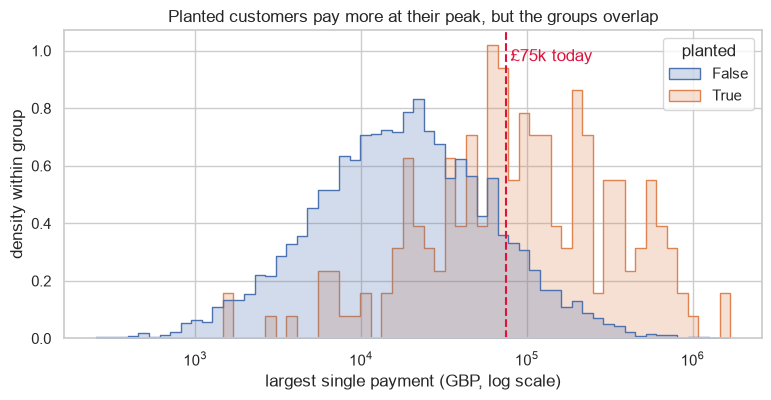

In [3]:
fig, ax = plt.subplots(figsize=(9, 4))
sns.histplot(customers, x="max_amount", hue="planted", log_scale=True, element="step",
             stat="density", common_norm=False, bins=60, ax=ax)
ax.axvline(75_000, ls="--", c="crimson")
ax.text(80_000, ax.get_ylim()[1] * 0.9, "£75k today", color="crimson")
ax.set(xlabel="largest single payment (GBP, log scale)", ylabel="density within group",
       title="Planted customers pay more at their peak, but the groups overlap")
plt.show()

## Exercise 3 — the confusion matrix for `high_value` at £75k

The rule works at **customer grain**: alert if any payment exceeds the threshold.

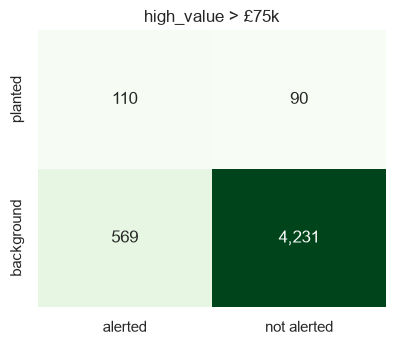

alerts       679.000
precision      0.162
recall         0.550
fpr            0.119
f1             0.250
lift           4.050
accuracy       0.868
dtype: float64

In [4]:
y_true = customers.planted.to_numpy()
y_pred = (customers.max_amount > 75_000).to_numpy()
r = metrics.evaluate(y_true.tolist(), y_pred.tolist())

cm = confusion_matrix(y_true, y_pred, labels=[True, False])   # rows: truth, cols: alert
fig, ax = plt.subplots(figsize=(4.5, 3.6))
sns.heatmap(cm, annot=True, fmt=",", cbar=False, cmap="Greens",
            xticklabels=["alerted", "not alerted"], yticklabels=["planted", "background"], ax=ax)
ax.set_title("high_value > £75k")
plt.show()

pd.Series({k: r[k] for k in ("alerts", "precision", "recall", "fpr", "f1", "lift", "accuracy")}).round(3)

## Exercise 4 — the accuracy trap

Compare today's rule with a rule that **never alerts**.

In [5]:
nothing = metrics.evaluate(y_true.tolist(), [False] * len(y_true))
print("never-alert precision is", repr(nothing["precision"]), "-- pandas will show it as NaN below")
pd.DataFrame({"high_value > £75k": r, "never alert": nothing}).loc[
    ["alerts", "tp", "accuracy", "recall", "precision"]]

never-alert precision is None -- pandas will show it as NaN below


,high_value > £75k,never alert
alerts,679.000000,0.00
tp,110.000000,0.00
accuracy,0.868200,0.96
recall,0.550000,0.00
precision,0.162003,NaN


The do-nothing rule is **more accurate** and catches **nothing**. Its precision is `None`, not 0: with no alerts, precision is undefined.
The studio shows undefined as undefined; scikit-learn would print 0.0.

## Exercise 5 — why the curriculum's week-2 exercise had no answer

The external curriculum drew its label as `binomial(1, 0.04)`, **independent of amount**.
Below, precision across thresholds for that random label, against TM-SIM's planted label, whose behaviour **causes** the label.

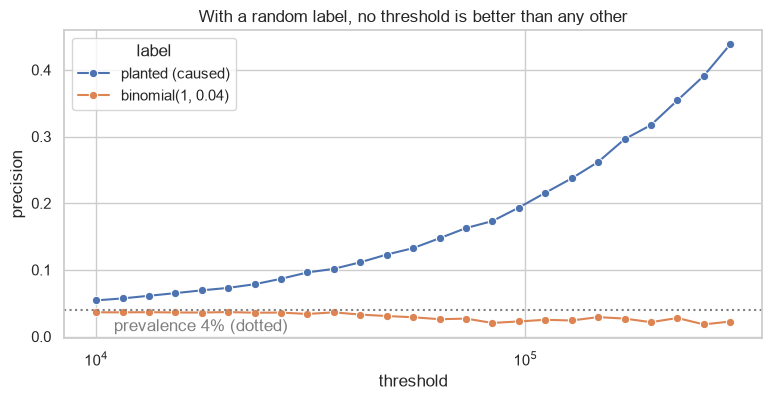

In [6]:
rng = np.random.default_rng(42)
random_label = rng.binomial(1, 0.04, len(customers)).astype(bool)

rows = []
for t in np.geomspace(10_000, 300_000, 25):
    alert = (customers.max_amount > t).tolist()
    for name, label in (("planted (caused)", y_true), ("binomial(1, 0.04)", random_label)):
        e = metrics.evaluate(label.tolist(), alert)
        rows.append({"threshold": t, "label": name, "precision": e["precision"], "recall": e["recall"]})
sweep = pd.DataFrame(rows)

fig, ax = plt.subplots(figsize=(9, 4))
sns.lineplot(sweep, x="threshold", y="precision", hue="label", marker="o", ax=ax)
ax.axhline(0.04, ls=":", c="grey"); ax.text(11_000, 0.008, "prevalence 4% (dotted)", color="grey")
ax.set(xscale="log", title="With a random label, no threshold is better than any other")
plt.show()

With the random label, precision sits at the prevalence line wherever the threshold is: there is no operating point to find.
fc-10 guards against TM-SIM ever becoming that: `test_the_label_is_caused.py` requires lift ≥ 3 at £75k, and a **negative control** (same labels, behaviour removed) must show none.

## Exercise 6 — the blind spot a flat threshold has

A planted spike is relative to the customer's **own** scale. Which planted customers does £75k miss?

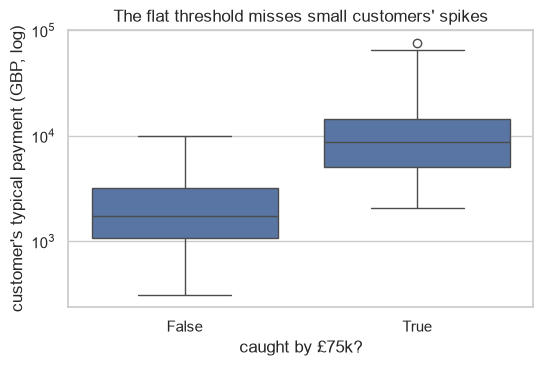

,count,median
caught,,
False,90,1739.0
True,110,8749.0


In [7]:
planted = customers[customers.planted].assign(caught=lambda d: d.max_amount > 75_000)
fig, ax = plt.subplots(figsize=(6, 3.6))
sns.boxplot(planted, x="caught", y="scale", log_scale=True, ax=ax)
ax.set(xlabel="caught by £75k?", ylabel="customer's typical payment (GBP, log)",
       title="The flat threshold misses small customers' spikes")
plt.show()
planted.groupby("caught").scale.agg(["count", "median"]).round(0)

A £30k payment from a customer who usually sends £2k is a 15× spike, and it sits below £75k.
A flat threshold can't see relative change. Week 5 (segments) and the behavioural rules ask whether a different design would do better, and at what alert volume.

## Your answers (the curriculum's success criteria)

Write two or three sentences each. Use numbers from this notebook.

1. **False-negative risk.** What does the FN box cost a bank, and how many planted customers did £75k miss?

    *…*

2. **False-positive cost.** How many alerts did £75k raise that were not planted, and what does that mean for an investigator team working 300 a day?

    *…*

3. **Why accuracy is a poor metric in AML.** Use Exercise 4.

    *…*